<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment No. 3
## Logistic Regression, Sigmoid Function & Classification Metrics

---

###  Aim
To implement **Logistic Regression from scratch** using the Sigmoid function for a binary classification problem, and evaluate the model using classification metrics — **TPR, FPR, TNR, FNR, Recall, Precision, Sensitivity** — and plot the **ROC-AUC Curve**.

---

###  Theory

####  Why not Linear Regression for Classification?
Linear Regression predicts **continuous values** (e.g., 2.5, 7.8). But for classification, we need the output to be a **probability between 0 and 1** — representing the chance of belonging to a class.

If we apply Linear Regression directly, the output can go beyond [0, 1], which makes no sense as a probability.

**Solution → Use the Sigmoid Function!**

---

####  Sigmoid Function
The Sigmoid function squashes any real number into the range **(0, 1)**:

**σ(z) = 1 / (1 + e⁻ᶻ)**

Where:
- **z = w·X + b** (linear combination of inputs)
- Output close to **1** → model predicts Class 1
- Output close to **0** → model predicts Class 0

The decision boundary is at **σ(z) = 0.5**, i.e., when **z = 0**.

---

####  Binary Cross-Entropy Cost Function
For classification, MSE is not ideal. We use **Binary Cross-Entropy (Log Loss)**:

**J(w,b) = -(1/m) · Σ [ yᵢ·log(ŷᵢ) + (1-yᵢ)·log(1-ŷᵢ) ]**

- When y=1 and ŷ≈1 → loss ≈ 0 (correct prediction)
- When y=1 and ŷ≈0 → loss → ∞ (wrong prediction, heavy penalty)

---

####  Gradient Descent for Logistic Regression
The update rules are the same form as Linear Regression:

- **w = w - α · (1/m) · Xᵀ · (ŷ - y)**
- **b = b - α · (1/m) · Σ(ŷ - y)**

Where **α** is the learning rate.

---

####  Decision Boundary
After training, we classify:
- If **σ(z) ≥ 0.5** → predict **Class 1**
- If **σ(z) < 0.5** → predict **Class 0**

The line where **σ(z) = 0.5** (i.e., **w·X + b = 0**) is called the **Decision Boundary**.

In [1]:
# Import required libraries
import numpy as np               # For numerical operations and matrix math
import pandas as pd              # For organizing data in tabular form
import matplotlib.pyplot as plt  # For plotting graphs and visualizations

print("Libraries imported successfully!")

Libraries imported successfully!


---
###  Step 1: Generate Dataset

We create a **synthetic binary classification dataset** with two classes:
- **Class 0** — points clustered around (3, 3)
- **Class 1** — points clustered around (5, 5)

Each class has 50 samples, giving us 100 total data points with 2 features (x1, x2).

In [2]:
np.random.seed(42)

# Class 0: 50 points centered at (3, 3) with spread 1.5
c0 = np.random.randn(50, 2) * 1.5 + [3, 3]

# Class 1: 50 points centered at (5, 5) with spread 1.5
c1 = np.random.randn(50, 2) * 1.5 + [5, 5]

# Stack both classes vertically
X = np.vstack((c0, c1))

# Labels: 0 for class 0, 1 for class 1
y = np.array([0]*50 + [1]*50)

# Store in DataFrame
data = pd.DataFrame(X, columns=["x1", "x2"])
data["y"] = y

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Dataset shape: (100, 3)

First 5 rows:
         x1        x2  y
0  3.745071  2.792604  0
1  3.971533  5.284545  0
2  2.648770  2.648795  0
3  5.368819  4.151152  0
4  2.295788  3.813840  0


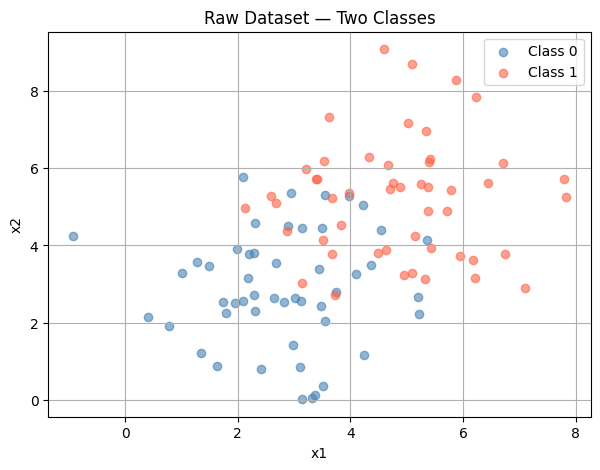

In [3]:
# Visualize the two classes before training
plt.figure(figsize=(7, 5))

# Plot Class 0 points
plt.scatter(data[data["y"] == 0]["x1"], data[data["y"] == 0]["x2"],
            color='steelblue', label='Class 0', alpha=0.6)

# Plot Class 1 points
plt.scatter(data[data["y"] == 1]["x1"], data[data["y"] == 1]["x2"],
            color='tomato', label='Class 1', alpha=0.6)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Raw Dataset — Two Classes")
plt.legend()
plt.grid(True)
plt.show()

---
### ✂️ Step 2: Train-Test Split

We shuffle the data and split it:
- **80%** → Training set (used to learn weights)
- **20%** → Test set (used to evaluate the trained model)

In [4]:
# Shuffle the data randomly
data = data.sample(frac=1).reset_index(drop=True)

# 80-20 split
split = int(0.8 * len(data))

train = data[:split]
test  = data[split:]

# Extract feature matrices and label vectors
X_train = train[["x1", "x2"]].values
y_train = train["y"].values

X_test = test[["x1", "x2"]].values
y_test = test["y"].values

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 80
Test size: 20


---
###  Step 3: Train Logistic Regression using Gradient Descent

For each epoch:
1. **Forward Pass** — compute z = X·w + b, then apply sigmoid → ŷ
2. **Compute Cost** — Binary Cross-Entropy loss
3. **Compute Gradients** — how much to change w and b
4. **Update Parameters** — w and b move in the direction of decreasing cost

We stop early if the cost change between epochs is smaller than our tolerance (convergence).

In [5]:
# Get number of training samples (m) and features (n)
m, n = X_train.shape

# Initialize weights to zero
w = np.zeros(n)   # one weight per feature
b = 0             # bias term

cost = []         # to track cost at every epoch

# Hyperparameters
alpha     = 0.1    # learning rate
epochs    = 2000   # maximum number of iterations
tolerance = 1e-5   # early stopping threshold

for i in range(epochs):

    # --- Forward Pass ---
    # Linear combination: z = X·w + b
    z  = np.dot(X_train, w) + b

    # Apply sigmoid to get probability ŷ (between 0 and 1)
    yi = 1 / (1 + np.exp(-z))

    # --- Compute Binary Cross-Entropy Cost ---
    eps = 1e-10   # small value to avoid log(0) which is undefined
    J = (-1 / m) * np.sum(
        y_train * np.log(yi + eps) +
        (1 - y_train) * np.log(1 - yi + eps)
    )

    cost.append(J)

    # --- Compute Gradients ---
    dw = (1 / m) * np.dot(X_train.T, (yi - y_train))  # gradient w.r.t weights
    db = (1 / m) * np.sum(yi - y_train)               # gradient w.r.t bias

    # --- Update Parameters ---
    w = w - alpha * dw
    b = b - alpha * db

    # --- Early Stopping ---
    if i > 0 and abs(cost[i] - cost[i-1]) < tolerance:
        print("Stopped at epoch", i)
        break

    if i % 100 == 0:
        print("Epoch", i, "Cost =", round(J, 4))

print("w =", w)
print("b =", b)

Epoch 0 Cost = 0.6931
Epoch 100 Cost = 0.5244
Epoch 200 Cost = 0.4695
Epoch 300 Cost = 0.433
Epoch 400 Cost = 0.4076
Epoch 500 Cost = 0.3891
Epoch 600 Cost = 0.3752
Epoch 700 Cost = 0.3644
Epoch 800 Cost = 0.3558
Epoch 900 Cost = 0.3489
Epoch 1000 Cost = 0.3431
Epoch 1100 Cost = 0.3383
Epoch 1200 Cost = 0.3343
Epoch 1300 Cost = 0.3308
Epoch 1400 Cost = 0.3278
Epoch 1500 Cost = 0.3252
Epoch 1600 Cost = 0.323
Epoch 1700 Cost = 0.321
Epoch 1800 Cost = 0.3192
Epoch 1900 Cost = 0.3177
w = [0.84565405 0.84853624]
b = -6.197614039450103


---
###  Step 4: Predict on Test Set

We apply the learned weights to the test set:
1. Compute **z = X_test · w + b**
2. Apply **sigmoid** → probabilities
3. Apply **threshold 0.5** → if probability ≥ 0.5, predict Class 1, else Class 0

In [6]:
# Compute linear output for test set
z  = np.dot(X_test, w) + b

# Apply sigmoid to get predicted probabilities
yi = 1 / (1 + np.exp(-z))

# Convert probabilities to class labels using threshold = 0.5
y_pred = np.where(yi > 0.5, 1, 0)

# Compute accuracy: fraction of correctly predicted labels
acc = np.mean(y_pred == y_test)
print("Accuracy:", acc)

Accuracy: 0.8


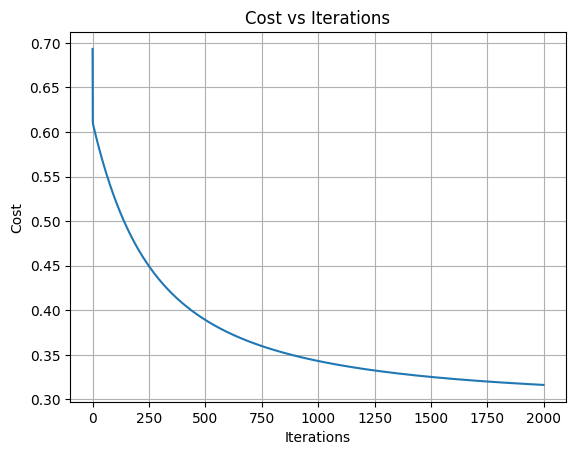

In [7]:
# Plot cost over iterations to verify the model converged
plt.figure()
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.grid()
plt.show()

---
###  Step 5: Plot Decision Boundary

The **Decision Boundary** is the line where the model is exactly 50% confident — i.e., where **w·X + b = 0**.

For 2 features (x1, x2):
**w[0]·x1 + w[1]·x2 + b = 0**

Solving for x2:
**x2 = -(w[0]·x1 + b) / w[1]**

Points on one side of this line → Class 1, on the other side → Class 0.

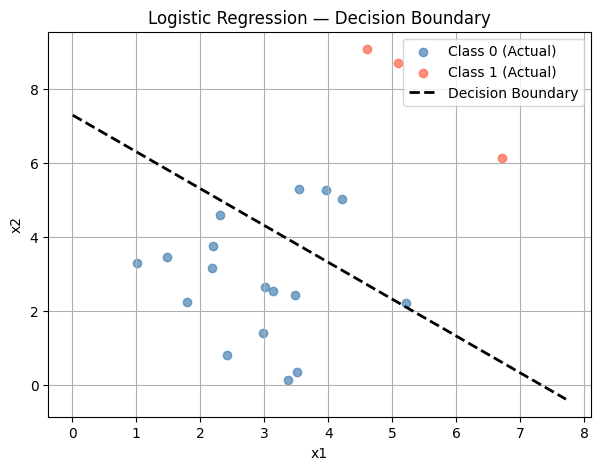

In [8]:
plt.figure(figsize=(7, 5))

# Plot Class 0 test points
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
            color='steelblue', label='Class 0 (Actual)', alpha=0.7)

# Plot Class 1 test points
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
            color='tomato', label='Class 1 (Actual)', alpha=0.7)

# Compute and plot the decision boundary line: x2 = -(w[0]*x1 + b) / w[1]
x1_vals = np.linspace(X_test[:, 0].min() - 1, X_test[:, 0].max() + 1, 200)
x2_vals = -(w[0] * x1_vals + b) / w[1]

plt.plot(x1_vals, x2_vals, color='black', linewidth=2, linestyle='--',
         label='Decision Boundary')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression — Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

---
###  Step 6: Classification Metrics — Confusion Matrix

Before computing metrics, we build a **Confusion Matrix**:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN (True Negative) | FP (False Positive) |
| **Actual 1** | FN (False Negative) | TP (True Positive) |

From the confusion matrix, we derive:

| Metric | Formula | Meaning |
|---|---|---|
| **TPR / Recall / Sensitivity** | TP / (TP + FN) | Of all actual positives, how many did we catch? |
| **TNR / Specificity** | TN / (TN + FP) | Of all actual negatives, how many did we correctly reject? |
| **FPR** | FP / (FP + TN) | Of all actual negatives, how many did we wrongly flag? |
| **FNR** | FN / (FN + TP) | Of all actual positives, how many did we miss? |
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many were actually positive? |

Note: **TPR = Recall = Sensitivity** — they are all the same metric, just different names used in different fields.

In [9]:
# --- Build Confusion Matrix manually ---

# True Positive: predicted 1, actual 1
TP = np.sum((y_pred == 1) & (y_test == 1))

# True Negative: predicted 0, actual 0
TN = np.sum((y_pred == 0) & (y_test == 0))

# False Positive: predicted 1, actual 0 (Type I Error)
FP = np.sum((y_pred == 1) & (y_test == 0))

# False Negative: predicted 0, actual 1 (Type II Error)
FN = np.sum((y_pred == 0) & (y_test == 1))

print("=== Confusion Matrix ===")
print(f"  TP = {TP}  |  FP = {FP}")
print(f"  FN = {FN}  |  TN = {TN}")

# --- Compute Metrics ---
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0   # True Positive Rate = Recall = Sensitivity
TNR = TN / (TN + FP) if (TN + FP) > 0 else 0   # True Negative Rate = Specificity
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0   # False Positive Rate
FNR = FN / (FN + TP) if (FN + TP) > 0 else 0   # False Negative Rate
Precision  = TP / (TP + FP) if (TP + FP) > 0 else 0  # Precision
Recall     = TPR                                       # Same as TPR
Sensitivity = TPR                                      # Same as TPR

print("\n=== Classification Metrics ===")
print(f"  TPR (True Positive Rate)  = Recall = Sensitivity = {TPR:.4f}")
print(f"  TNR (True Negative Rate)  = Specificity          = {TNR:.4f}")
print(f"  FPR (False Positive Rate) =                        {FPR:.4f}")
print(f"  FNR (False Negative Rate) =                        {FNR:.4f}")
print(f"  Precision                 =                        {Precision:.4f}")
print(f"  Recall                    =                        {Recall:.4f}")
print(f"  Accuracy                  =                        {acc:.4f}")

=== Confusion Matrix ===
  TP = 3  |  FP = 4
  FN = 0  |  TN = 13

=== Classification Metrics ===
  TPR (True Positive Rate)  = Recall = Sensitivity = 1.0000
  TNR (True Negative Rate)  = Specificity          = 0.7647
  FPR (False Positive Rate) =                        0.2353
  FNR (False Negative Rate) =                        0.0000
  Precision                 =                        0.4286
  Recall                    =                        1.0000
  Accuracy                  =                        0.8000


---
### 📈 Step 7: ROC Curve & AUC

#### What is the ROC Curve?
The **ROC (Receiver Operating Characteristic) Curve** is a graph that shows model performance **across all possible classification thresholds** (not just 0.5).

- **X-axis** → FPR (False Positive Rate) — how often we wrongly predict positive
- **Y-axis** → TPR (True Positive Rate / Recall) — how often we correctly predict positive

By varying the threshold from 0 → 1, we get a curve. A **perfect classifier** hugs the top-left corner.

#### What is AUC?
**AUC (Area Under the Curve)** is a single number summarizing the ROC curve:
- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random guessing (diagonal line)
- **AUC < 0.5** → Worse than random

We compute AUC using the **Trapezoidal Rule** — approximating the area under the curve numerically.

In [11]:
# Use the raw predicted probabilities (yi) computed earlier on the test set
# We vary the threshold from 0 to 1 and compute TPR and FPR at each threshold

# Recompute probabilities cleanly
z_test   = np.dot(X_test, w) + b
probs    = 1 / (1 + np.exp(-z_test))   # predicted probabilities for test set

# Generate a range of thresholds from 0 to 1
thresholds = np.linspace(0, 1, 200)

tpr_list = []   # store TPR at each threshold
fpr_list = []   # store FPR at each threshold

for threshold in thresholds:

    # Predict class based on current threshold
    y_thresh = np.where(probs >= threshold, 1, 0)

    # Compute TP, TN, FP, FN
    tp = np.sum((y_thresh == 1) & (y_test == 1))
    tn = np.sum((y_thresh == 0) & (y_test == 0))
    fp = np.sum((y_thresh == 1) & (y_test == 0))
    fn = np.sum((y_thresh == 0) & (y_test == 1))

    # Compute TPR and FPR for this threshold
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

# Convert to arrays
tpr_arr = np.array(tpr_list)
fpr_arr = np.array(fpr_list)

# Compute AUC using the Trapezoidal Rule
# np.trapz integrates area under the curve numerically
# We sort by FPR so the curve goes left to right
sort_idx = np.argsort(fpr_arr)
AUC = np.trapz(tpr_arr[sort_idx], fpr_arr[sort_idx])

print(f"AUC Score = {AUC:.4f}")

AUC Score = 1.0000


/tmp/ipykernel_11373/1450456958.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC = np.trapz(tpr_arr[sort_idx], fpr_arr[sort_idx])


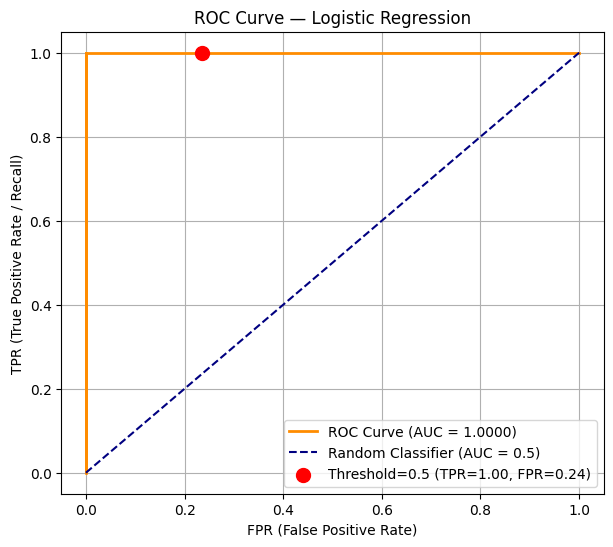

In [12]:
plt.figure(figsize=(7, 6))

# Plot the ROC curve
plt.plot(fpr_arr[sort_idx], tpr_arr[sort_idx],
         color='darkorange', linewidth=2, label=f'ROC Curve (AUC = {AUC:.4f})')

# Plot the diagonal — represents a random classifier
plt.plot([0, 1], [0, 1], color='navy', linewidth=1.5,
         linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the point at threshold = 0.5 (our default threshold)
plt.scatter([FPR], [TPR], color='red', zorder=5, s=100,
            label=f'Threshold=0.5 (TPR={TPR:.2f}, FPR={FPR:.2f})')

plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate / Recall)")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

---
###  Conclusion

In this experiment, we:

1. **Implemented Logistic Regression from scratch** using the **Sigmoid function** to convert linear outputs into probabilities.

2. **Trained the model** using **Binary Cross-Entropy Loss** minimized via **Gradient Descent**.

3. **Plotted the Decision Boundary** — the line that separates Class 0 from Class 1.

4. **Computed all Classification Metrics** from the Confusion Matrix:
   - **TPR = Recall = Sensitivity** → ability to detect positives
   - **TNR = Specificity** → ability to reject negatives
   - **FPR** → rate of false alarms
   - **FNR** → rate of missed positives
   - **Precision** → quality of positive predictions

5. **Plotted the ROC Curve** and computed **AUC** — a threshold-independent measure of model quality.

**Key Insight:** A high AUC (close to 1.0) means the model can cleanly separate the two classes across all thresholds, not just at 0.5.